In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from statsmodels.tsa.stattools import adfuller
from Src.Data_utils import differencing
from Src.Data_utils import cointegration
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns


load_dotenv()

##Connect to sql database
engine = create_engine(
    f"mysql+pymysql://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@"
    f"{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DB')}"
)

##Load the data from SQL

data = pd.read_sql("SELECT * FROM GDP_inference_clean", engine)

data.columns = ["date", "Labor Productivity", "Unemployment Rate", "Federal Funds Rate", "Inflation", "GDP", "Population"]

data["GDP_per_capita"] = data["GDP"] / data["Population"]
print(data)

          date  Labor Productivity  Unemployment Rate  Federal Funds Rate  \
0   1999-01-01                 4.1                4.3                4.07   
1   1999-04-01                 3.9                4.3                5.41   
2   1999-07-01                 3.5                4.3                5.76   
3   1999-10-01                 4.2                4.1                5.26   
4   2000-01-01                 2.4                4.0                3.99   
..         ...                 ...                ...                 ...   
102 2024-07-01                 2.6                4.2                5.33   
103 2024-10-01                 1.9                4.1                4.83   
104 2025-01-01                 1.2                4.0                4.33   
105 2025-04-01                 1.5                4.2                4.33   
106 2025-07-01                 1.9                4.3                4.33   

     Inflation        GDP  Population  GDP_per_capita  
0     2.383116   94

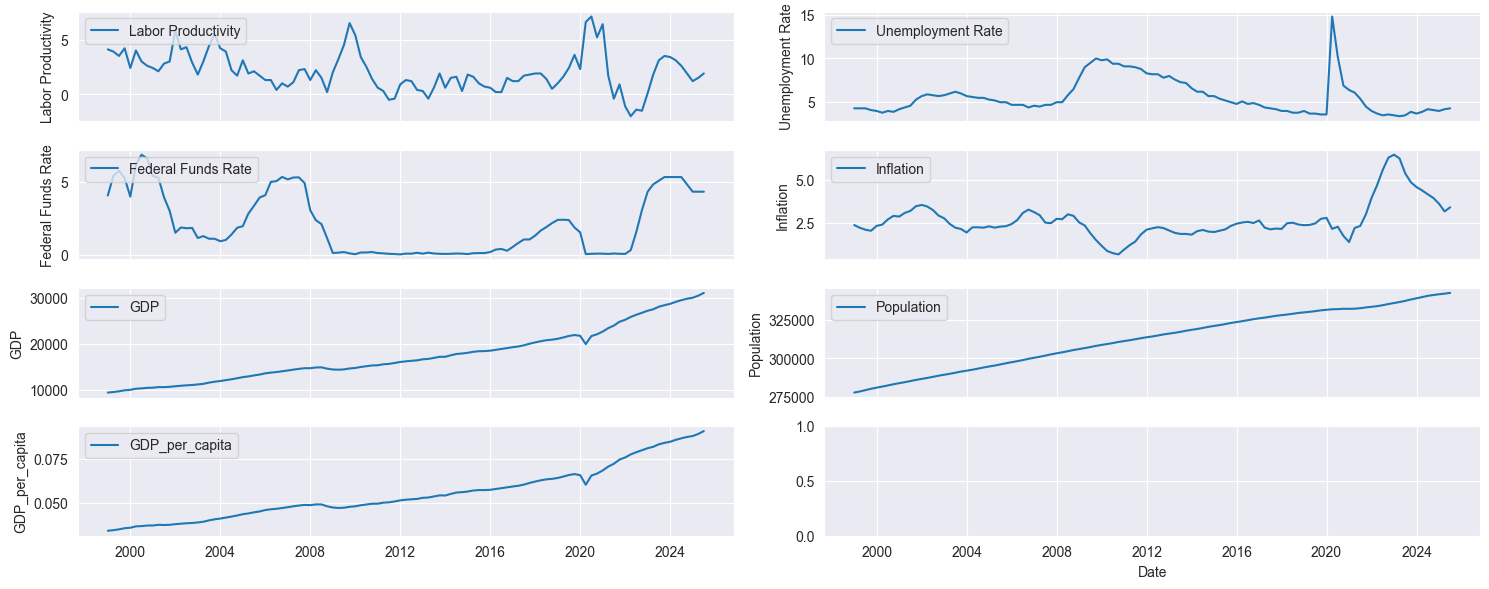

In [2]:

fig, axes = plt.subplots(4, 2, figsize=(15, 6), sharex=True)
axes = axes.flatten()
for i, column in enumerate(data.columns[1:]):
    axes[i].plot(data["date"], data[column], label=column, color='tab:blue')
    axes[i].set_ylabel(column)
    axes[i].legend(loc='upper left')

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [3]:
##Calculates unit roots to formally test stationarity
def dickey_fuller_test(data_test):
    if "date" in data_test.columns:
        data_test = data_test.drop(["date"], axis=1)
    for i in data_test.columns:
        adf_result = adfuller(data_test[i], regression="ct")
        print(f"{i}, ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}")


dickey_fuller_test(data)

Labor Productivity, ADF Statistic: -2.4955453580689055, p-value: 0.3301930237233174
Unemployment Rate, ADF Statistic: -3.396929753568123, p-value: 0.05179948499800715
Federal Funds Rate, ADF Statistic: -2.8240389252123133, p-value: 0.18825536864148473
Inflation, ADF Statistic: -1.1312624273508463, p-value: 0.9236651207888141
GDP, ADF Statistic: 0.8460930490056591, p-value: 1.0
Population, ADF Statistic: -0.07041065283265054, p-value: 0.9934461257884178
GDP_per_capita, ADF Statistic: 0.5400818770449792, p-value: 0.9969174794279753


In [4]:
##Differencing the data and calculating Dickey Fuller on the new data
Differenced_data = differencing(data)
dickey_fuller_test(Differenced_data)

diffed_Labor Productivity, ADF Statistic: -4.810471936453128, p-value: 0.0004490142850188881
diffed_Unemployment Rate, ADF Statistic: -9.395931872872362, p-value: 4.7150835160859746e-14
diffed_Federal Funds Rate, ADF Statistic: -4.843904928110718, p-value: 0.0003921024682678999
diffed_Inflation, ADF Statistic: -3.4954329314069184, p-value: 0.03988239101877941
diffed_GDP, ADF Statistic: -11.04982538250591, p-value: 1.7910497002663715e-17
diffed_Population, ADF Statistic: -4.475427793528878, p-value: 0.0016554266954871158
diffed_GDP_per_capita, ADF Statistic: -10.940158893596788, p-value: 2.894875044137563e-17


In [5]:
##This function tests cointgeration between every time series combination and returns the p-values and significant combinations

cointegration(data)

(                    date  Labor Productivity  Unemployment Rate  \
 date                 NaN                 NaN                NaN   
 Labor Productivity   NaN                 NaN           0.534453   
 Unemployment Rate    NaN            0.534453                NaN   
 Federal Funds Rate   NaN            0.158534           0.004760   
 Inflation            NaN            0.385583           0.004449   
 GDP                  NaN            0.333189           0.031631   
 Population           NaN            0.247687           0.041885   
 GDP_per_capita       NaN            0.349094           0.031475   
 
                     Federal Funds Rate  Inflation       GDP  Population  \
 date                               NaN        NaN       NaN         NaN   
 Labor Productivity            0.158534   0.385583  0.333189    0.247687   
 Unemployment Rate             0.004760   0.004449  0.031631    0.041885   
 Federal Funds Rate                 NaN   0.011388  0.058593    0.134887   
 Infla

In [6]:
##Calculate descriptive statistics on stationary time series
Differenced_data.describe()

,diffed_Labor Productivity,diffed_Unemployment Rate,diffed_Federal Funds Rate,diffed_Inflation,diffed_GDP,diffed_Population,diffed_GDP_per_capita
count,106.000000,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000
mean,-0.020755,4.189521e-18,0.002453,0.009780,204.588160,608.292453,0.000537
std,1.184963,1.269120e+00,0.573028,0.306003,299.919498,159.160594,0.000902
min,-4.700000,-4.600000e+00,-1.860000,-0.864819,-1792.947000,-34.000000,-0.005465
25%,-0.775000,-2.000000e-01,-0.060000,-0.158407,113.652750,543.750000,0.000271
50%,-0.100000,-1.000000e-01,0.005000,-0.009177,187.899500,635.500000,0.000492
75%,0.700000,1.000000e-01,0.207500,0.190768,269.705000,713.250000,0.000778
max,4.300000,1.120000e+01,2.180000,0.957764,1746.146000,889.000000,0.005242


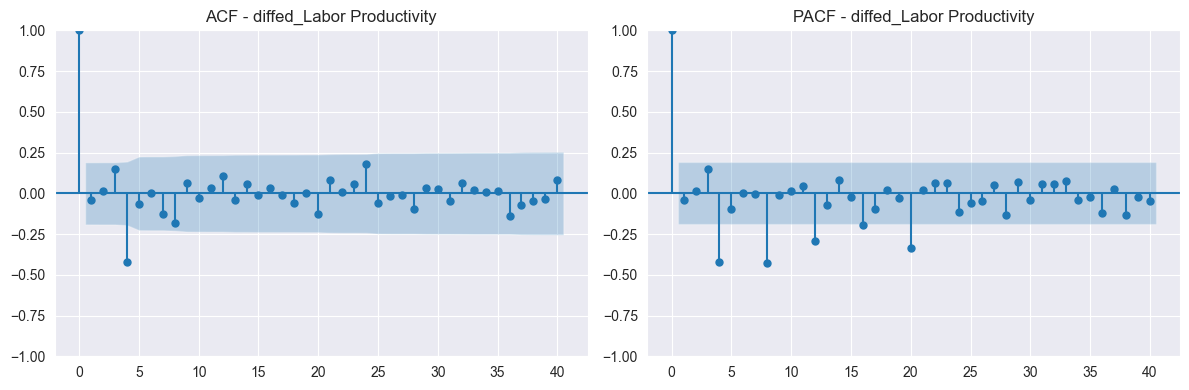

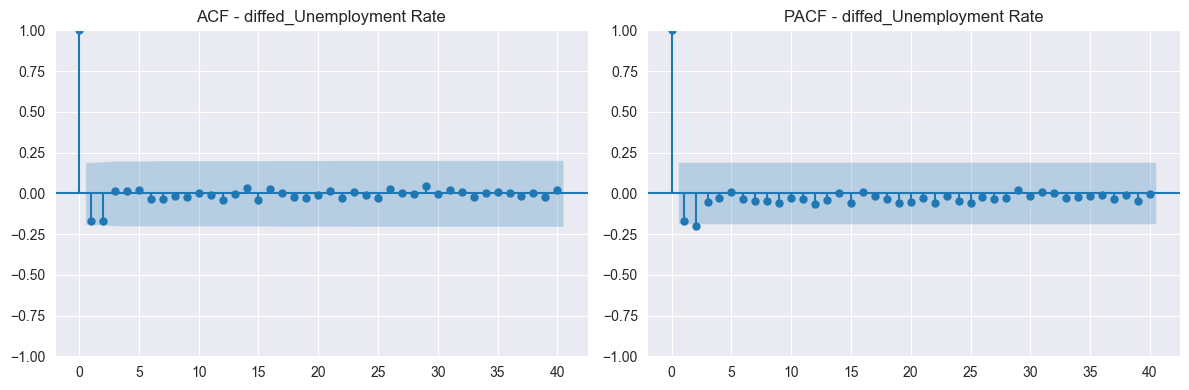

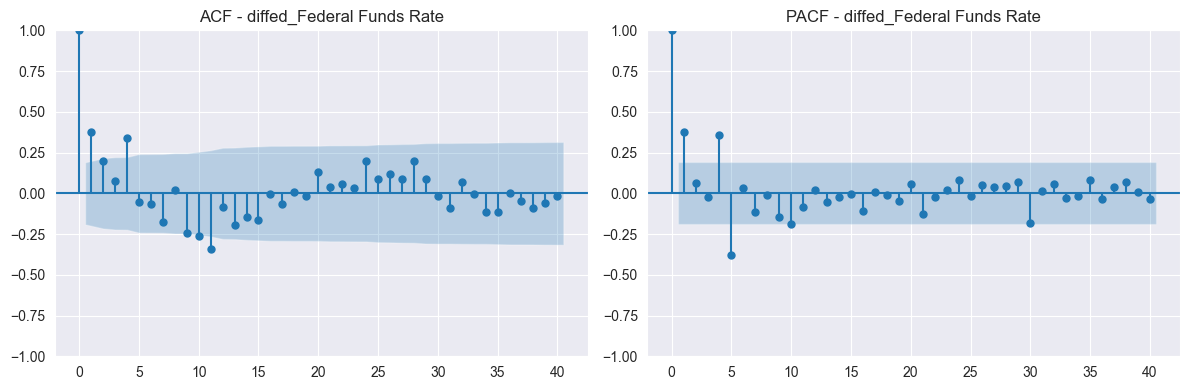

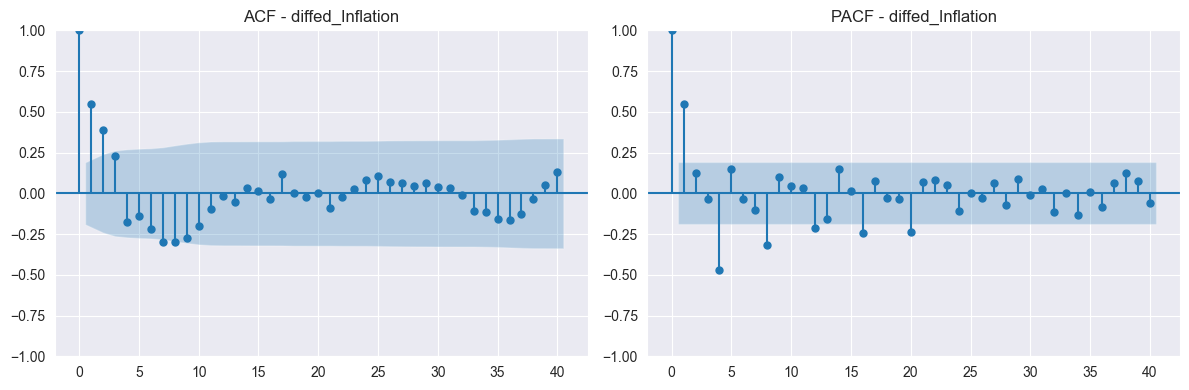

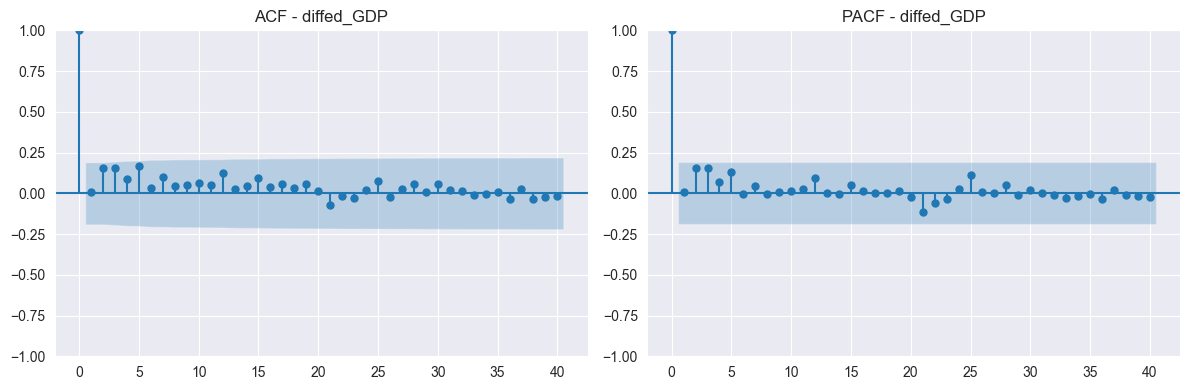

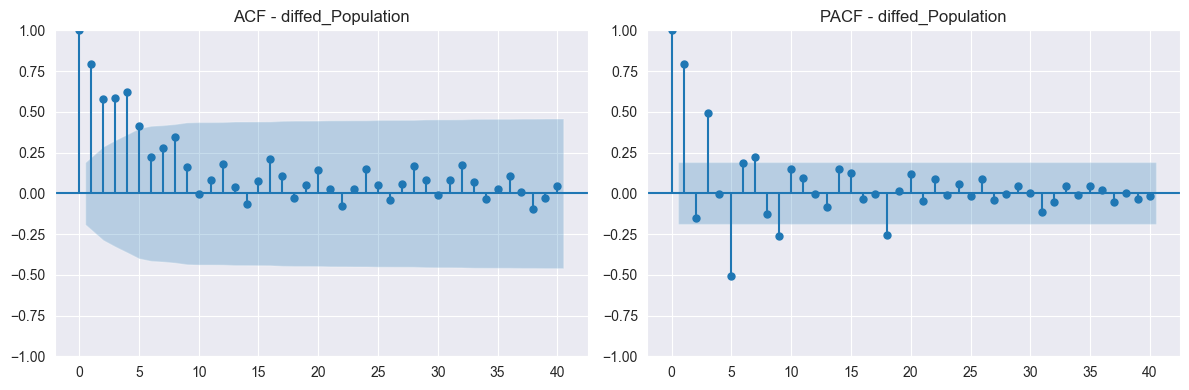

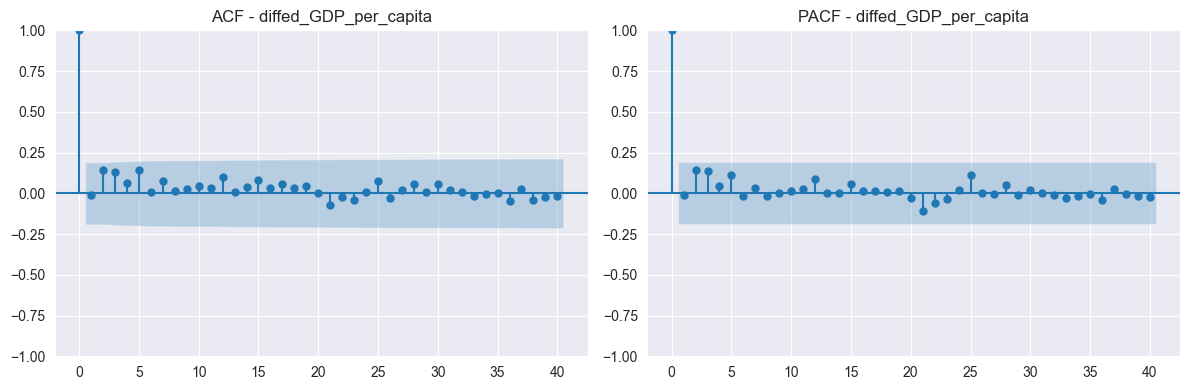

In [7]:
for column in Differenced_data.columns:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(Differenced_data[column].dropna(), ax=axes[0], lags=40)
    axes[0].set_title(f"ACF - {column}")

    plot_pacf(Differenced_data[column].dropna(), ax=axes[1], lags=40, method="ywm")
    axes[1].set_title(f"PACF - {column}")

    plt.tight_layout()
    plt.show()

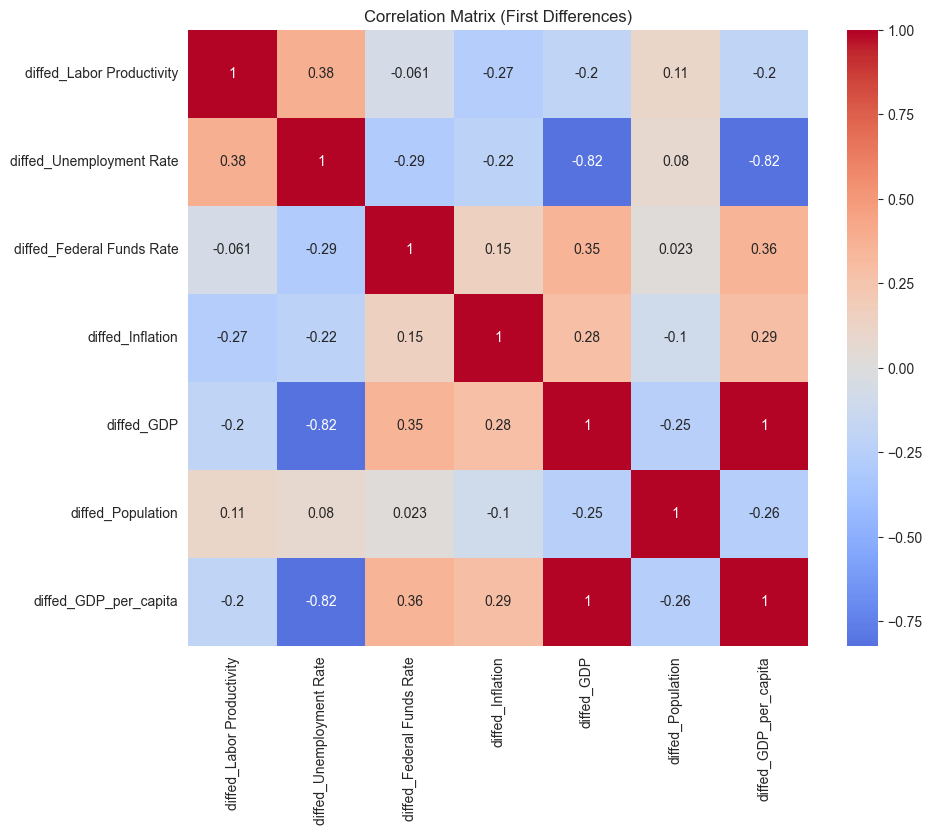

In [8]:
corr_diff = Differenced_data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_diff, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (First Differences)")
plt.show()
